## LLM Setup

In [1]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    temperature=0,
    groq_api_key=api_key,
    model_name="llama-3.3-70b-versatile"
)

# Adding the JSON Parser
parser = JsonOutputParser()

## Scraping a job posting page

In [2]:
from langchain_community.document_loaders import WebBaseLoader

loader = WebBaseLoader("https://kenya.ai/opportunities/lead-data-scientist-at-kyosk-digital-services/?utm_campaign=google_jobs_apply&utm_source=google_jobs_apply&utm_medium=organic")
page_data = loader.load().pop().page_content
# print(page_data)

USER_AGENT environment variable not set, consider setting it to identify your requests.


## Extracting job data

In [3]:
prompt_extract = PromptTemplate.from_template(
"""
You are an expert information extraction system.

### CONTEXT
The following text was scraped from a company's career page and contains
information about a job posting. The text may include formatting noise,
navigation elements, or repeated content.

### TASK
Extract the job information from the text.

Return a JSON object with the following fields:

- role: The job title
- experience: Required experience level (years or level such as junior, mid, senior)
- skills: List of key technical or domain skills required for the role
- description: A concise 2–5 sentence summary of the job responsibilities

### RULES
- Extract information only from the provided text.
- Do NOT invent information.
- If a field is missing, return null.
- Skills must be returned as a list of strings.
- Return ONLY a valid JSON object.
- Do not include explanations, markdown, backticks, or extra text

### JSON FORMAT
{{
  "role": "Job title",
  "experience": "Experience requirement",
  "skills": ["skill1", "skill2", "skill3"],
  "description": "Short description of the role"
}}

### SCRAPED TEXT
{page_data}
"""
)

# Building the extract chain
chain_extract = prompt_extract | llm | parser

In [4]:
# Running the chain extraction on the scraped jd
job_data = chain_extract.invoke({"page_data": page_data})
print(job_data)

{'role': 'Lead Data Scientist', 'experience': 'Minimum of 3 years', 'skills': ['R', 'Python', 'SQL', 'Java', 'Scala', 'C++', 'JavaScript', 'Machine learning', 'Data mining', 'Data visualization', 'Looker Studio', 'Statistical programming languages'], 'description': 'The Lead Data Scientist will be responsible for discovering insights from complex data sets and building models to support business objectives and decision-making. The role holder will provide new insights into the business and utilize advanced statistical analysis, data mining, and data visualization techniques to create solutions that enable enhanced business performance. The Lead Data Scientist will work with stakeholders to identify opportunities for leveraging company data to drive business solutions and lead project execution to ensure that data projects are completed on time and according to service delivery specifications.'}


## Extracting resume data

In [5]:
import pdfplumber

def read_resume(path="resume.pdf"):
    text = ""
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
    return text

resume_text = read_resume()
print(resume_text[:1000])

Sharlyn Muturi
Portfolio:sharlynmuturi.github.io
(+254)748-736720 github.com/sharlynmuturi
DataScientist/AIEngineer/Underwriter
sharlynnmuturi@gmail.com
Analyticalactuarialsciencegraduatewithexperienceininsuranceoperations,claimsanalytics,policyevaluation,andrisk
assessment.Strongbackgroundinstatisticalmodelingandmachinelearning.ProficientinPython,R,SQL,andDjangoORMfor
dataanalysisanddata-drivenapplicationdesign,withexperiencebuildingLLM-poweredapplications.Interestedinapplyingdata
andAItodevelopscalablesolutionsthatsupportinformeddecision-makinginanalyticsandrisk-focusedenvironments.
SKILLS
ProgrammingandWeb Python,R,SQL,JavaScript,HTML/CSS,Django,Flask,Streamlit.
Data&Analytics Databricks,Tableau,PowerBI,SQLServer,MySQL,PostgreSQL,Spark,Excel,Access,A/Btesting.
AIEngineering PromptEngineering,LangChain,RAG,OpenAI,Groq,HuggingFace,GenAI,AgenticAI,DocumentAI.
MachineLearning RegressionandClassificationModels,TimeSeriesAnalysis,PredictiveModeling,NLP,NeuralNetworks.
InsuranceOperations 

In [6]:
prompt_resume = PromptTemplate.from_template(
"""
You are an expert resume parser.

### TASK
Extract structured information from the resume text.

Return a JSON object with the following fields:

- name: candidate name
- education: list of education entries
- skills: list of technical skills
- experience: list of professional experiences
- projects: list of projects mentioned

### RULES
- Extract information only from the text.
- Do NOT invent information.
- If something is missing return null.
- Skills must be a list of strings.
- Return ONLY valid JSON.

### JSON FORMAT
{{
  "name": "Candidate name",
  "education": ["degree1", "degree2"],
  "skills": ["skill1", "skill2"],
  "experience": ["experience1", "experience2"],
  "projects": ["project1", "project2"]
}}

### RESUME TEXT
{resume_text}
"""
)

parser = JsonOutputParser()

chain_resume = prompt_resume | llm | parser

# Running the resume extraction
resume_data = chain_resume.invoke({"resume_text": resume_text})

print(resume_data)

{'name': 'Sharlyn Muturi', 'education': ['Bachelor of Science in Actuarial Science, GPA: 3.5, The University of Nairobi 2020—2024', 'Kenya Certificate of Secondary Education (K.C.S.E), Grade: A-, Chogoria Girls’ High School 2016—2019'], 'skills': ['Python', 'R', 'SQL', 'JavaScript', 'HTML/CSS', 'Django', 'Flask', 'Streamlit', 'Databricks', 'Tableau', 'PowerBI', 'SQL Server', 'MySQL', 'PostgreSQL', 'Spark', 'Excel', 'Access', 'A/B testing', 'Prompt Engineering', 'LangChain', 'RAG', 'OpenAI', 'Groq', 'Hugging Face', 'GenAI', 'AgenticAI', 'DocumentAI', 'Regression and Classification Models', 'Time Series Analysis', 'Predictive Modeling', 'NLP', 'Neural Networks'], 'experience': ['UNDERWRITING ASSISTANT, Incourage Insurance Agency, Nairobi, Kenya, Dec 2024—June 2025', 'INSURANCE OFFICER ATTACHEE, Kenya Electricity Generating Company PLC (KenGen), Nairobi, Kenya, May 2023—Jul 2023'], 'projects': ['JiBudget - Personal finance and budgeting web application', 'Motor Insurance System - System s

In [7]:
print("\nCandidate:", resume_data["name"])
print("\nSkills:", ", ".join(resume_data["skills"]))
print("\nEducation:", resume_data["education"])
print("\nProjects:", resume_data["projects"])


Candidate: Sharlyn Muturi

Skills: Python, R, SQL, JavaScript, HTML/CSS, Django, Flask, Streamlit, Databricks, Tableau, PowerBI, SQL Server, MySQL, PostgreSQL, Spark, Excel, Access, A/B testing, Prompt Engineering, LangChain, RAG, OpenAI, Groq, Hugging Face, GenAI, AgenticAI, DocumentAI, Regression and Classification Models, Time Series Analysis, Predictive Modeling, NLP, Neural Networks

Education: ['Bachelor of Science in Actuarial Science, GPA: 3.5, The University of Nairobi 2020—2024', 'Kenya Certificate of Secondary Education (K.C.S.E), Grade: A-, Chogoria Girls’ High School 2016—2019']

Projects: ['JiBudget - Personal finance and budgeting web application', 'Motor Insurance System - System supporting policy issuance, underwriting workflows and data storage', 'M-PESA Transactions Analytics - Platform that analyzes M-PESA statements using regex and LLMs', 'AI Resume & Job Matching - AI assistant using RAG, LangChain, Groq, ChromaDB and Hugging Face', 'Portfolio Optimization - Comb

In [8]:
job_skills = set(job_data["skills"])
resume_skills = set(resume_data["skills"])

matching = job_skills.intersection(resume_skills)

print("Matching skills:", matching)

Matching skills: {'R', 'JavaScript', 'Python', 'SQL'}


## Embedding Portfolio Projects

In [9]:
import pandas as pd

portfolio_df = pd.read_csv("portfolio.csv")
portfolio_df.head(2)

,project_name,description,tech_stack,link,source_page,all_text
0,JiBudget,Personal finance and budgeting web application...,"bootstrap, css, django, html, html/css, javasc...",https://github.com/sharlynmuturi/JiBudget,https://sharlynmuturi.github.io/,JiBudget Personal finance and budgeting web ap...
1,Motor Insurance Database,Database-driven insurance management system su...,"bootstrap, css, django, html, html/css, mysql,...",https://github.com/sharlynmuturi/motor-insuran...,https://sharlynmuturi.github.io/,Motor Insurance Database Database-driven insur...


In [10]:
import uuid
import chromadb

# ChromaDB for portfolio
client = chromadb.PersistentClient('vectorstore')
collection = client.get_or_create_collection(name="portfolio")

if not collection.count():
    for _, row in portfolio_df.iterrows():
        collection.add(
            documents=[row["all_text"]],
            metadatas={
                "link": row.get("link",""),
                "project_name": row.get("project_name",""),
                "tech_stack": row.get("tech_stack","")
            },
            ids=[str(uuid.uuid4())]
        )

print(f"Total projects in ChromaDB: {collection.count()}")

Total projects in ChromaDB: 20


In [11]:
# Retrieving Portfolio Projects
job_description_text = job_data["description"]

# Querying chromaDB for relevant projects
results = collection.query(
    query_texts=[job_description_text],
    n_results=5  # top 5 most relevant projects
)

# Format top projects for the LLM
top_projects_text = ""
for doc, meta in zip(results['documents'][0], results['metadatas'][0]):
    project_name = meta.get("project_name", "Unknown Project")
    tech_stack = meta.get("tech_stack", "")
    link = meta.get("link", "")

    top_projects_text += f"""
Project: {project_name}
Description: {doc}
Technologies: {tech_stack}
Link: {link}
"""

print(top_projects_text[:800])


Project: HR Data Analysis & Visualization
Description: HR Data Analysis & Visualization Exploratory data analysis and building interactive dashboards to analyze workforce and organizational metrics. analysis
Technologies: analysis
Link: https://github.com/sharlynmuturi/data-engineering-and-analytics-projects/tree/main/customer-shopping-behavior-analysis

Project: Product & Customer Sales Performance ETL
Description: Product & Customer Sales Performance ETL End-to-end customer and product sales analytics pipeline, including data ingestion, aggregation, feature engineering, performance analysis and visualization. analysis, analytics, visualization
Technologies: analysis, analytics, visualization
Link: https://github.com/sharlynmuturi/data-engineering-and-analytics-projects/tree/main/custome


## Resume and Cover Letter Tailoring

In [12]:
prompt_tailor_resume = PromptTemplate.from_template(
"""
You are an expert career assistant and resume writer.

Your task is to tailor a candidate's resume for a specific job role.

### JOB DESCRIPTION
{job_data}

### CANDIDATE RESUME
{resume_data}

### CANDIDATE PROJECTS
{portfolio_projects}

### INSTRUCTIONS
Rewrite the candidate's resume so that it better aligns with the job.

Focus on:
- highlighting relevant skills
- emphasizing relevant projects
- matching the language used in the job description
- keeping all information truthful

### OUTPUT FORMAT

Return a professional resume with the following sections:

NAME

PROFESSIONAL SUMMARY

SKILLS

EXPERIENCE

PROJECTS

EDUCATION

The resume should be concise, professional, and optimized for ATS systems.

Return only the resume text.
"""
)

chain_tailor_resume = prompt_tailor_resume | llm

In [13]:
tailored_resume = chain_tailor_resume.invoke({
    "job_data": job_data,
    "resume_data": resume_text,
    "portfolio_projects": top_projects_text
})

print("TAILORED RESUME\n")
print(tailored_resume.content)

TAILORED RESUME

Sharlyn Muturi

PROFESSIONAL SUMMARY
Results-driven Lead Data Scientist with 1+ year of experience in data analysis, machine learning, and statistical modeling. Proven ability to discover insights from complex data sets and build models to support business objectives and decision-making. Proficient in a range of programming languages, including Python, R, SQL, and JavaScript, with a strong background in data visualization and statistical analysis.

SKILLS
- Programming languages: Python, R, SQL, JavaScript, HTML/CSS
- Data analysis and visualization: Tableau, PowerBI, Databricks, SQL Server, MySQL, PostgreSQL, Spark
- Machine learning: Regression and Classification Models, Time Series Analysis, Predictive Modeling, NLP, Neural Networks
- Data mining and statistical analysis: Data visualization, statistical programming languages, Looker Studio
- Operating Systems: Windows, Linux

EXPERIENCE
UNDERWRITING ASSISTANT
Incourage Insurance Agency, Nairobi, Kenya
Dec 2024 — Jun

In [14]:
prompt_cover_letter = PromptTemplate.from_template("""
You are an expert career assistant.

### CONTEXT
You have the following information:

- Job posting details: {job_data}
- Candidate resume content: {resume_data}
- Relevant portfolio projects: {portfolio_projects}

### TASK
Write a professional and persuasive **cover letter** tailored to this specific job. 
The cover letter should:

1. Address the hiring manager (use "Dear Hiring Manager" if name is unknown)
2. Highlight the candidate's most relevant skills and experience from the resume
3. Reference the most relevant portfolio projects
4. Match the tone of the job posting (formal, professional)
5. Be 3–5 paragraphs long
6. End with a polite call-to-action

### RULES
- Only use information provided in the context; do not invent details
- Keep it concise and impactful
- Output plain text (no JSON)
""")

chain_cover_letter = prompt_cover_letter | llm

res_cover_letter = chain_cover_letter.invoke({
    "job_data": job_data,
    "resume_data": resume_text,
    "portfolio_projects": top_projects_text
})

# output
cover_letter_text = res_cover_letter["content"] if isinstance(res_cover_letter, dict) else res_cover_letter.content

print("AI GENERATED COVER LETTER \n")
print(cover_letter_text)

AI GENERATED COVER LETTER 

Dear Hiring Manager,

I am excited to apply for the Lead Data Scientist position at your esteemed organization. With a strong background in statistical modeling and machine learning, I am confident in my ability to discover insights from complex data sets and build models to support business objectives and decision-making. My experience in insurance operations, claims analytics, and policy evaluation has equipped me with a unique understanding of the importance of data-driven decision-making in driving business solutions.

As a skilled data scientist with proficiency in Python, R, SQL, and Django ORM, I have a proven track record of building data-driven applications and analyzing complex data sets. My experience in machine learning, data mining, and data visualization has enabled me to develop scalable solutions that support informed decision-making in analytics and risk-focused environments. I am excited about the opportunity to leverage my skills and exper

## Semantic Matching

In [17]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

def get_embedding_model():
    return HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

embedding_model = get_embedding_model()

In [32]:
def cosine_sim(a, b):
    return dot(a, b) / (norm(a) * norm(b))

### Portfolio projects + Job Requirements

In [18]:
# Embedding job
description = job_data.get("description") or ""
skills_list = job_data.get("skills") or []
job_text = description + " " + " ".join(skills_list)

job_embedding = embedding_model.embed_documents([job_text])[0]

In [19]:
# Embedding portfolio projects
project_texts = portfolio_df['all_text'].tolist()
project_embeddings = embedding_model.embed_documents(project_texts)

In [20]:
# Computing cosine similarity (document-level similarity)
# One job embedding (combined text: description + skills) compared to each project
from numpy import dot
from numpy.linalg import norm

similarities = [cosine_sim(job_embedding, p_emb) for p_emb in project_embeddings]

In [21]:
# Get top 5 projects
top_indices = sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True)[:5]
top_semantic_projects = portfolio_df.iloc[top_indices]
top_semantic_projects

,project_name,description,tech_stack,link,source_page,all_text
15,HR Data Analysis & Visualization,Exploratory data analysis and building interac...,analysis,https://github.com/sharlynmuturi/data-engineer...,https://sharlynmuturi.github.io/elements.html,HR Data Analysis & Visualization Exploratory d...
12,Product & Customer Sales Performance ETL,End-to-end customer and product sales analytic...,"analysis, analytics, visualization",https://github.com/sharlynmuturi/data-engineer...,https://sharlynmuturi.github.io/elements.html,Product & Customer Sales Performance ETL End-t...
13,Sales Data Warehouse and Analytics,Star-schema data warehouse and analytical repo...,"data warehouse, sql, tableau",https://github.com/sharlynmuturi/data-engineer...,https://sharlynmuturi.github.io/elements.html,Sales Data Warehouse and Analytics Star-schema...
6,SaaS Customer Churn Prediction and Retention,Developed an end-to-end SaaS customer churn pl...,"analysis, customer churn, machine learning, sh...",https://github.com/sharlynmuturi/machine-learn...,https://sharlynmuturi.github.io/generic.html,SaaS Customer Churn Prediction and Retention D...
4,Stock Forecasting & Portfolio Optimization,AI-driven system that applies machine learning...,"ai, ai agents, machine learning, prophet, stat...",https://github.com/sharlynmuturi/AI-Stock-Port...,https://sharlynmuturi.github.io/,Stock Forecasting & Portfolio Optimization AI-...


### Skill Gap Analysis using semantic search

In [22]:
def extract_portfolio_skills(text):
    skills = set()

    for line in text.split("\n"):
        line = line.lower()

        if "technologies:" in line:
            techs = line.replace("technologies:", "").split(",")
            skills.update([t.strip() for t in techs if t.strip()])

        # detect keywords in descriptions
        keywords = [
        "python", "r", "sql", "javascript", "html", "css", "html/css", "bootstrap", "django", "flask", "streamlit",
        "pytorch", "tensorflow", "prophet", "llms", "rag", "langchain", "hugging face", "huggingface", "openai", "groq", "chromadb", "prompt engineering", "llama",
        "spark", "databricks", "mysql database", "sqlite", "mysql", "postgresql", "sql server", "ssms", "access", "mongodb",
        "tableau", "power bi", "excel", "a/b testing", "mlflow", "dvc", "regex", "ai", "tesseract", "ocr", "layoutlm", "nlp", "ai agents", "document ai",
        "machine learning", "statistics", "statistical modelling", "statistical methods", "statistical programming", "analysis", "analytics", "prediction", "forecasting", "fraud detection", "cnns",
        "shap", "survival analysis", "customer churn", "recommender systems", "nltk", "web scraping", "visualization", "data warehouse", "etl", "data transformation"
        ]

        for kw in keywords:
            if kw in line:
                skills.add(kw)

    return list(skills)

In [23]:
portfolio_skills = extract_portfolio_skills(top_projects_text) # embedded top projects

print("Portfolio Skills:", portfolio_skills)

Portfolio Skills: ['r', 'etl', 'customer churn', 'prediction', 'rag', 'data warehouse', 'analytics', 'analysis', 'visualization', 'tableau', 'survival analysis', 'machine learning', 'ai agents', 'prophet', 'sql', 'ai', 'forecasting', 'shap', 'statistical methods']


In [24]:
resume_skills_raw = resume_data.get("skills", [])

print("Resume Skills:", resume_skills_raw)

Resume Skills: ['Python', 'R', 'SQL', 'JavaScript', 'HTML/CSS', 'Django', 'Flask', 'Streamlit', 'Databricks', 'Tableau', 'PowerBI', 'SQL Server', 'MySQL', 'PostgreSQL', 'Spark', 'Excel', 'Access', 'A/B testing', 'Prompt Engineering', 'LangChain', 'RAG', 'OpenAI', 'Groq', 'Hugging Face', 'GenAI', 'AgenticAI', 'DocumentAI', 'Regression and Classification Models', 'Time Series Analysis', 'Predictive Modeling', 'NLP', 'Neural Networks']


In [25]:
combined_candidate_skills = resume_skills_raw + portfolio_skills

print("Combined Candidate Skills:", combined_candidate_skills)

Combined Candidate Skills: ['Python', 'R', 'SQL', 'JavaScript', 'HTML/CSS', 'Django', 'Flask', 'Streamlit', 'Databricks', 'Tableau', 'PowerBI', 'SQL Server', 'MySQL', 'PostgreSQL', 'Spark', 'Excel', 'Access', 'A/B testing', 'Prompt Engineering', 'LangChain', 'RAG', 'OpenAI', 'Groq', 'Hugging Face', 'GenAI', 'AgenticAI', 'DocumentAI', 'Regression and Classification Models', 'Time Series Analysis', 'Predictive Modeling', 'NLP', 'Neural Networks', 'r', 'etl', 'customer churn', 'prediction', 'rag', 'data warehouse', 'analytics', 'analysis', 'visualization', 'tableau', 'survival analysis', 'machine learning', 'ai agents', 'prophet', 'sql', 'ai', 'forecasting', 'shap', 'statistical methods']


In [26]:
job_skills_raw = job_data.get("skills", [])
job_description = job_data.get("description", "")

print("Job Skills:", job_skills_raw)

Job Skills: ['R', 'Python', 'SQL', 'Java', 'Scala', 'C++', 'JavaScript', 'Machine learning', 'Data mining', 'Data visualization', 'Looker Studio', 'Statistical programming languages']


In [27]:
import re

def normalize_skills(skills_list):
    normalized = set()
    
    if not skills_list:
        return normalized
    
    for skill in skills_list:
        if not skill:
            continue
        skill = skill.lower().strip()

        # Extract text inside parentheses and split by comma
        paren_matches = re.findall(r'\((.*?)\)', skill)
        for match in paren_matches:
            for s in match.split(','):
                s = s.strip()
                if s:
                    normalized.add(s)

        # Remove parentheses part from main skill
        skill = re.sub(r'\(.*?\)', '', skill).strip()
        
        # Split remaining text by commas
        for s in skill.split(','):
            s = s.strip()
            if s:
                normalized.add(s)
    
    return normalized

In [28]:
job_skills = list(normalize_skills(job_skills_raw))
candidate_skills = list(normalize_skills(combined_candidate_skills))

print("Normalized Job Skills:", job_skills)
print("\nNormalized Candidate Skills:", candidate_skills)

Normalized Job Skills: ['sql', 'data visualization', 'r', 'machine learning', 'javascript', 'python', 'data mining', 'java', 'scala', 'looker studio', 'c++', 'statistical programming languages']

Normalized Candidate Skills: ['r', 'a/b testing', 'nlp', 'hugging face', 'etl', 'prompt engineering', 'html/css', 'customer churn', 'databricks', 'prediction', 'rag', 'streamlit', 'data warehouse', 'analytics', 'analysis', 'langchain', 'visualization', 'django', 'time series analysis', 'neural networks', 'excel', 'tableau', 'sql server', 'groq', 'regression and classification models', 'survival analysis', 'machine learning', 'spark', 'predictive modeling', 'javascript', 'ai agents', 'mysql', 'access', 'prophet', 'agenticai', 'sql', 'ai', 'postgresql', 'powerbi', 'forecasting', 'shap', 'genai', 'documentai', 'openai', 'python', 'statistical methods', 'flask']


In [29]:
if job_description:
    job_skills_with_context = job_skills + [job_description]
else:
    job_skills_with_context = job_skills

print("Job Skills + Context:", job_skills_with_context)

Job Skills + Context: ['sql', 'data visualization', 'r', 'machine learning', 'javascript', 'python', 'data mining', 'java', 'scala', 'looker studio', 'c++', 'statistical programming languages', 'The Lead Data Scientist will be responsible for discovering insights from complex data sets and building models to support business objectives and decision-making. The role holder will provide new insights into the business and utilize advanced statistical analysis, data mining, and data visualization techniques to create solutions that enable enhanced business performance. The Lead Data Scientist will work with stakeholders to identify opportunities for leveraging company data to drive business solutions and lead project execution to ensure that data projects are completed on time and according to service delivery specifications.']


In [30]:
embedding_model = get_embedding_model()

job_embeddings = embedding_model.embed_documents(job_skills_with_context)
candidate_embeddings = embedding_model.embed_documents(candidate_skills)

print("Job Embeddings Shape:", len(job_embeddings))
print("Candidate Embeddings Shape:", len(candidate_embeddings))

Job Embeddings Shape: 13
Candidate Embeddings Shape: 47


In [33]:
# Similarity matrix (semantic matching)
# compare each job skill embedding to each candidate skill

similarity_matrix = []

for i, job_emb in enumerate(job_embeddings[:len(job_skills)]):  # ignore description row
    row = []
    for cand_emb in candidate_embeddings:
        sim = cosine_sim(job_emb, cand_emb)
        row.append(sim)
    similarity_matrix.append(row)

df_sim = pd.DataFrame(similarity_matrix, index=job_skills, columns=candidate_skills)

df_sim.round(2)

,r,a/b testing,nlp,hugging face,etl,prompt engineering,html/css,customer churn,databricks,prediction,...,postgresql,powerbi,forecasting,shap,genai,documentai,openai,python,statistical methods,flask
sql,0.23,0.20,0.28,0.05,0.23,0.28,0.21,0.23,0.20,0.21,...,0.51,0.19,0.20,0.22,0.13,0.12,0.17,0.30,0.28,0.13
data visualization,0.16,0.04,0.17,0.05,0.19,0.22,0.17,0.13,0.40,0.22,...,0.27,0.11,0.22,0.13,0.04,0.11,0.10,0.25,0.30,0.10
r,1.00,0.15,0.28,0.26,0.28,0.19,0.11,0.20,0.17,0.30,...,0.09,0.31,0.24,0.27,0.28,0.22,0.31,0.29,0.09,0.19
machine learning,0.19,0.18,0.42,0.14,0.30,0.26,0.26,0.23,0.23,0.59,...,0.15,0.23,0.44,0.31,0.17,0.21,0.22,0.36,0.50,0.16
javascript,0.15,0.13,0.19,0.04,0.13,0.21,0.41,0.09,0.04,0.22,...,0.15,0.17,0.18,0.15,0.08,0.16,0.12,0.31,0.20,0.18
python,0.29,0.13,0.26,0.15,0.30,0.29,0.24,0.13,0.30,0.27,...,0.22,0.20,0.22,0.32,0.22,0.28,0.29,1.00,0.24,0.48
data mining,0.19,0.14,0.33,0.11,0.26,0.21,0.20,0.33,0.28,0.49,...,0.24,0.23,0.40,0.23,0.15,0.19,0.22,0.33,0.54,0.13
java,0.29,0.16,0.22,0.11,0.25,0.30,0.25,0.14,0.21,0.25,...,0.25,0.22,0.22,0.29,0.23,0.23,0.29,0.45,0.17,0.19
scala,0.27,0.17,0.13,0.16,0.24,0.12,0.11,0.19,0.19,0.25,...,0.24,0.16,0.25,0.30,0.27,0.22,0.29,0.35,0.10,0.24
looker studio,0.21,0.09,0.14,0.16,0.22,0.23,0.15,0.03,0.25,0.15,...,0.16,0.21,0.16,0.24,0.13,0.24,0.29,0.26,0.12,0.14


In [34]:
def semantic_skill_match(job_skills, candidate_skills, embedding_model, threshold=0.5):
    matches = []
    missing = []

    job_embeddings = embedding_model.embed_documents(job_skills)
    candidate_embeddings = embedding_model.embed_documents(candidate_skills)

    for i, job_skill in enumerate(job_skills):
        job_emb = job_embeddings[i]
        
        # skip description
        if len(job_skill.split()) > 5:
            continue  
            
        best_match = None
        best_score = 0

        for j, cand_skill in enumerate(candidate_skills):
            sim = cosine_sim(job_emb, candidate_embeddings[j])

            if sim > best_score:
                best_score = sim
                best_match = cand_skill

        if best_score >= threshold:
            matches.append(f"{job_skill} - {best_match} ({best_score:.2f})")
        else:
            missing.append(job_skill)

    return matches, missing

In [35]:
matched_skills, missing_skills = semantic_skill_match(job_skills_with_context, candidate_skills, embedding_model, threshold=0.5)

print("Matched Skills:", matched_skills)
print("\nMissing Skills:", missing_skills)

Matched Skills: ['sql - sql (1.00)', 'data visualization - visualization (0.86)', 'r - r (1.00)', 'machine learning - machine learning (1.00)', 'javascript - javascript (1.00)', 'python - python (1.00)', 'data mining - machine learning (0.72)']

Missing Skills: ['java', 'scala', 'looker studio', 'c++', 'statistical programming languages']


In [36]:
match_score = len(matched_skills) / (len(matched_skills) + len(missing_skills))

print(f"Match Score: {match_score:.2%}")

Match Score: 58.33%


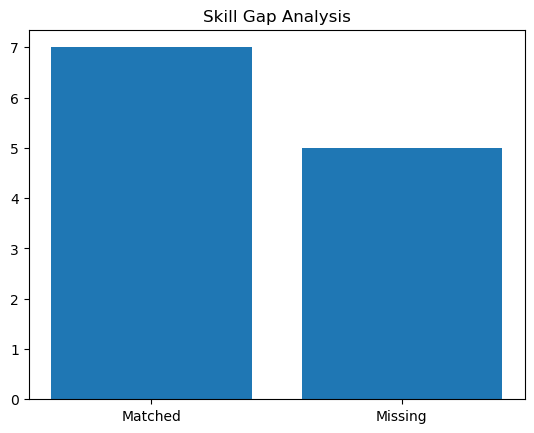

In [37]:
import matplotlib.pyplot as plt

labels = ['Matched', 'Missing']
values = [len(matched_skills), len(missing_skills)]

plt.bar(labels, values)
plt.title("Skill Gap Analysis")
plt.show()